# Deepfake Detection for KYC

## Universal Colab Setup

Run this notebook before starting any lab.

It will

- Clone GitHub
- Install libraries
- Configure Kaggle
- Download FaceForensics++
- Verify project

In [ ]:
# Clone repository

import os

os.chdir("/content")

!rm -rf Deepfake-Detection-KYC

!git clone https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git

%cd Deepfake-Detection-KYC

Cloning into 'Deepfake-Detection-KYC'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 124 (delta 60), reused 75 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (124/124), 1.57 MiB | 17.08 MiB/s, done.
Resolving deltas: 100% (60/60), done.
/content/Deepfake-Detection-KYC


In [ ]:
from pathlib import Path

print(Path.cwd())

!ls

/content/Deepfake-Detection-KYC
data  environment.yml  outputs	      README.md  requirements.txt
docs  notebooks        presentations  reports	 src


In [ ]:
!pip install -q kaggle pandas numpy matplotlib tqdm opencv-python==4.10.0.84

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 16.1 MB/s eta 0:00:00


In [ ]:
import os
from getpass import getpass

print("Configure Kaggle")

os.environ["KAGGLE_USERNAME"] = input("Username: ")
os.environ["KAGGLE_KEY"] = getpass("API Token: ")

print("Kaggle configured")

Configure Kaggle
Username: tanvi2609
API Token: ··········
Kaggle configured


In [ ]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 11.1 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [ ]:
!kaggle datasets list -s faceforensics


ref                                                              title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
greatgamedota/faceforensics                                      FaceForensics                                         724841395  2020-02-19 17:42:41.720000           4863         38  0.75             
xdxd003/ff-c23                                                   FaceForensics++ Dataset (C23)                       17891522096  2024-12-07 06:16:49.157000          51779        107  1                
hungle3401/faceforensics                                         FaceForensics++                                      2927395799  2024-02-13 04:35:27.907000           9020         26  0.3125  

In [ ]:
!kaggle datasets download -d xdxd003/ff-c23

Dataset URL: https://www.kaggle.com/datasets/xdxd003/ff-c23
License(s): other
100% 16.7G/16.7G [05:04<00:00, 58.7MB/s]



In [ ]:
!ls -lh

total 17G
drwxr-xr-x 6 root root 4.0K Jul 29 20:04 data
drwxr-xr-x 2 root root 4.0K Jul 29 20:04 docs
-rw-r--r-- 1 root root  206 Jul 29 20:04 environment.yml
-rw-r--r-- 1 root root  17G Dec  7  2024 ff-c23.zip
drwxr-xr-x 2 root root 4.0K Jul 29 20:04 notebooks
drwxr-xr-x 6 root root 4.0K Jul 29 20:04 outputs
drwxr-xr-x 2 root root 4.0K Jul 29 20:04 presentations
-rw-r--r-- 1 root root  960 Jul 29 20:04 README.md
drwxr-xr-x 2 root root 4.0K Jul 29 20:04 reports
-rw-r--r-- 1 root root    0 Jul 29 20:04 requirements.txt
drwxr-xr-x 8 root root 4.0K Jul 29 20:04 src


In [ ]:
!mkdir -p data/raw

In [ ]:
!unzip -q ff-c23.zip -d data/raw/

In [11]:
!find data/raw -maxdepth 2 -type d

data/raw
data/raw/FaceForensics++_C23
data/raw/FaceForensics++_C23/FaceShifter
data/raw/FaceForensics++_C23/original
data/raw/FaceForensics++_C23/csv
data/raw/FaceForensics++_C23/FaceSwap
data/raw/FaceForensics++_C23/NeuralTextures
data/raw/FaceForensics++_C23/DeepFakeDetection
data/raw/FaceForensics++_C23/Face2Face
data/raw/FaceForensics++_C23/Deepfakes


In [12]:
%cd /content/Deepfake-Detection-KYC

!find data/raw -maxdepth 2 -type d

/content/Deepfake-Detection-KYC
data/raw
data/raw/FaceForensics++_C23
data/raw/FaceForensics++_C23/FaceShifter
data/raw/FaceForensics++_C23/original
data/raw/FaceForensics++_C23/csv
data/raw/FaceForensics++_C23/FaceSwap
data/raw/FaceForensics++_C23/NeuralTextures
data/raw/FaceForensics++_C23/DeepFakeDetection
data/raw/FaceForensics++_C23/Face2Face
data/raw/FaceForensics++_C23/Deepfakes


In [13]:
import cv2

print(cv2.__version__)

4.10.0


In [14]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

In [15]:
from pathlib import Path

DATASET_PATH = Path("data/raw/FaceForensics++_C23/original")

videos = list(DATASET_PATH.rglob("*.mp4"))

print(f"Total videos found: {len(videos)}")

print("\nFirst 5 videos:")

for video in videos[:5]:
    print(video)

Total videos found: 1000

First 5 videos:
data/raw/FaceForensics++_C23/original/705.mp4
data/raw/FaceForensics++_C23/original/054.mp4
data/raw/FaceForensics++_C23/original/500.mp4
data/raw/FaceForensics++_C23/original/351.mp4
data/raw/FaceForensics++_C23/original/525.mp4


In [16]:
from pathlib import Path
import cv2

# Select one sample video
VIDEO_PATH = Path("data/raw/FaceForensics++_C23/original/003.mp4")

print("Video exists:", VIDEO_PATH.exists())

# Open video
cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise Exception("Could not open video.")

print("Video opened successfully!")

Video exists: True
Video opened successfully!


In [17]:
# Read first frame
ret, frame = cap.read()

if not ret:
    raise Exception("Could not read frame.")

print("Frame Shape:", frame.shape)

Frame Shape: (480, 640, 3)


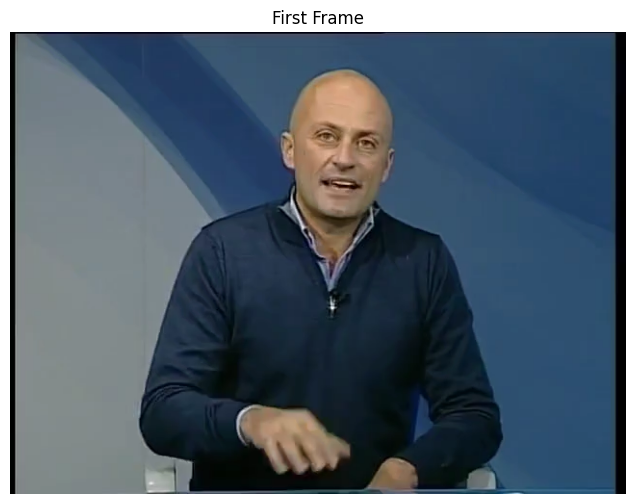

In [18]:
import matplotlib.pyplot as plt

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.title("First Frame")
plt.axis("off")
plt.show()

In [19]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("Cascade loaded:", not face_cascade.empty())

Cascade loaded: True


In [20]:
import cv2

print(cv2)
print(cv2.__file__)
print(cv2.__version__)

<module 'cv2' (<google.colab._import_hooks._hook_injector.HookInjectorLoader object at 0x791d4c3bf590>)>
/usr/local/lib/python3.12/dist-packages/cv2/__init__.py
4.10.0


In [21]:
print(hasattr(cv2, "CascadeClassifier"))

True


In [22]:
!find . -name "cv2.py"

In [23]:
import cv2

print("cv2 module:", cv2)
print("Location:", getattr(cv2, "__file__", "No __file__"))
print("Version:", getattr(cv2, "__version__", "No version"))
print("Has CascadeClassifier:", hasattr(cv2, "CascadeClassifier"))
print("First 20 attributes:")
print(dir(cv2)[:20])

cv2 module: <module 'cv2' (<google.colab._import_hooks._hook_injector.HookInjectorLoader object at 0x791d4c3bf590>)>
Location: /usr/local/lib/python3.12/dist-packages/cv2/__init__.py
Version: 4.10.0
Has CascadeClassifier: True
First 20 attributes:
['ACCESS_FAST', 'ACCESS_MASK', 'ACCESS_READ', 'ACCESS_RW', 'ACCESS_WRITE', 'ADAPTIVE_THRESH_GAUSSIAN_C', 'ADAPTIVE_THRESH_MEAN_C', 'AGAST_FEATURE_DETECTOR_AGAST_5_8', 'AGAST_FEATURE_DETECTOR_AGAST_7_12D', 'AGAST_FEATURE_DETECTOR_AGAST_7_12S', 'AGAST_FEATURE_DETECTOR_NONMAX_SUPPRESSION', 'AGAST_FEATURE_DETECTOR_OAST_9_16', 'AGAST_FEATURE_DETECTOR_THRESHOLD', 'AKAZE', 'AKAZE_DESCRIPTOR_KAZE', 'AKAZE_DESCRIPTOR_KAZE_UPRIGHT', 'AKAZE_DESCRIPTOR_MLDB', 'AKAZE_DESCRIPTOR_MLDB_UPRIGHT', 'AKAZE_create', 'AffineFeature']


In [24]:
import cv2

print(cv2.__version__)
print(hasattr(cv2, "CascadeClassifier"))

4.10.0
True


In [25]:
import cv2

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("Cascade loaded:", not face_cascade.empty())

Cascade loaded: True


In [26]:
# Convert image to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(50, 50)
)

print(f"Faces detected: {len(faces)}")

Faces detected: 1


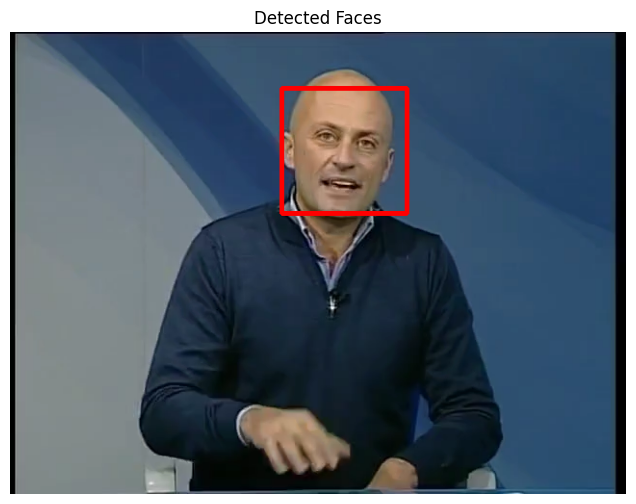

In [27]:
frame_copy = frame_rgb.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(
        frame_copy,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        3
    )

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(frame_copy)
plt.title("Detected Faces")
plt.axis("off")
plt.show()

In [28]:
cropped_faces = []

for (x, y, w, h) in faces:
    face = frame_rgb[y:y+h, x:x+w]
    cropped_faces.append(face)

print(f"Cropped {len(cropped_faces)} face(s)")

Cropped 1 face(s)


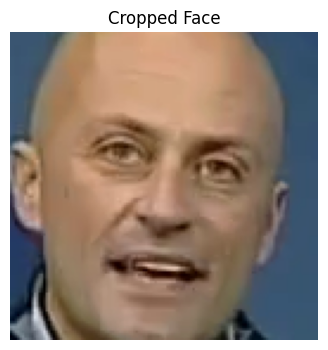

In [29]:
if cropped_faces:
    plt.figure(figsize=(4,4))
    plt.imshow(cropped_faces[0])
    plt.title("Cropped Face")
    plt.axis("off")
    plt.show()
else:
    print("No face detected.")

In [30]:
def load_face_detector():
    """
    Load OpenCV Haar Cascade face detector.
    """
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    if face_cascade.empty():
        raise RuntimeError("Failed to load Haar Cascade classifier.")

    return face_cascade

In [31]:
def detect_faces(image, face_cascade):
    """
    Detect faces in an image.

    Returns:
        faces: list of bounding boxes
    """

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 50)
    )

    return faces

In [32]:
def draw_faces(image, faces):
    """
    Draw rectangles around detected faces.
    """

    output = image.copy()

    for (x, y, w, h) in faces:
        cv2.rectangle(
            output,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            3
        )

    return output

In [33]:
def crop_faces(image, faces):
    """
    Crop detected faces from the image.
    """

    cropped = []

    for (x, y, w, h) in faces:
        face = image[y:y+h, x:x+w]
        cropped.append(face)

    return cropped

In [34]:
from pathlib import Path

def save_faces(faces, output_dir):
    """
    Save cropped faces.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for i, face in enumerate(faces):
        filename = output_dir / f"face_{i}.jpg"

        cv2.imwrite(
            str(filename),
            cv2.cvtColor(face, cv2.COLOR_RGB2BGR)
        )

    print(f"Saved {len(faces)} face(s).")

Faces found: 1


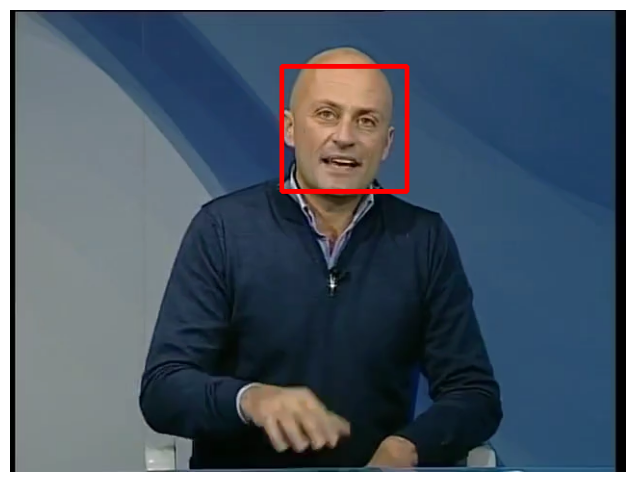

Saved 1 face(s).


In [35]:
face_detector = load_face_detector()

faces = detect_faces(frame, face_detector)

print("Faces found:", len(faces))

boxed = draw_faces(frame_rgb, faces)

cropped = crop_faces(frame_rgb, faces)

plt.figure(figsize=(8,6))
plt.imshow(boxed)
plt.axis("off")
plt.show()

save_faces(cropped, "data/processed/faces")